In [1]:
import pandas as pd
import numpy as np

# Step 2: Load datasets
dataset = pd.read_csv("train_preprocessed.csv")

In [2]:
dataset.cov()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,66231.000000,-0.626966,-7.561798,114.633461,-16.325843,-0.342697,161.883369,5.282022,-2.431461,2.552809
Survived,-0.626966,0.236772,-0.137703,-0.411226,-0.018954,0.032017,6.221787,-0.126376,0.000499,-0.032539
Pclass,-7.561798,-0.137703,0.699015,-3.699927,0.076599,0.012429,-22.830196,0.052712,0.051949,0.027660
Age,114.633461,-0.411226,-3.699927,169.512498,-3.349525,-1.810133,62.556767,0.505098,-0.114991,-0.039137
SibSp,-16.325843,-0.018954,0.076599,-3.349525,1.216043,0.368739,8.748734,-0.060422,-0.008170,0.033862
Parch,-0.342697,0.032017,0.012429,-1.810133,0.368739,0.649728,8.661052,-0.094584,-0.018408,0.021899
Fare,161.883369,6.221787,-22.830196,62.556767,8.748734,8.661052,2469.436846,-4.330946,-1.637606,-3.600584
Sex_male,5.282022,-0.126376,0.052712,0.505098,-0.060422,-0.094584,-4.330946,0.228475,-0.009960,0.025459
Embarked_Q,-2.431461,0.000499,0.051949,-0.114991,-0.008170,-0.018408,-1.637606,-0.009960,0.079040,-0.062727
Embarked_S,2.552809,-0.032539,0.027660,-0.039137,0.033862,0.021899,-3.600584,0.025459,-0.062727,0.199586


In [3]:
dataset.corr()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,0.042939,-0.033606,0.022204
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.543351,0.003650,-0.149683
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.131900,0.221009,0.074053
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.081163,-0.031415,-0.006729
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.114631,-0.026354,0.068734
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.245489,-0.081228,0.060814
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182333,-0.117216,-0.162184
Sex_male,0.042939,-0.543351,0.131900,0.081163,-0.114631,-0.245489,-0.182333,1.000000,-0.074115,0.119224
Embarked_Q,-0.033606,0.003650,0.221009,-0.031415,-0.026354,-0.081228,-0.117216,-0.074115,1.000000,-0.499421
Embarked_S,0.022204,-0.149683,0.074053,-0.006729,0.068734,0.060814,-0.162184,0.119224,-0.499421,1.000000


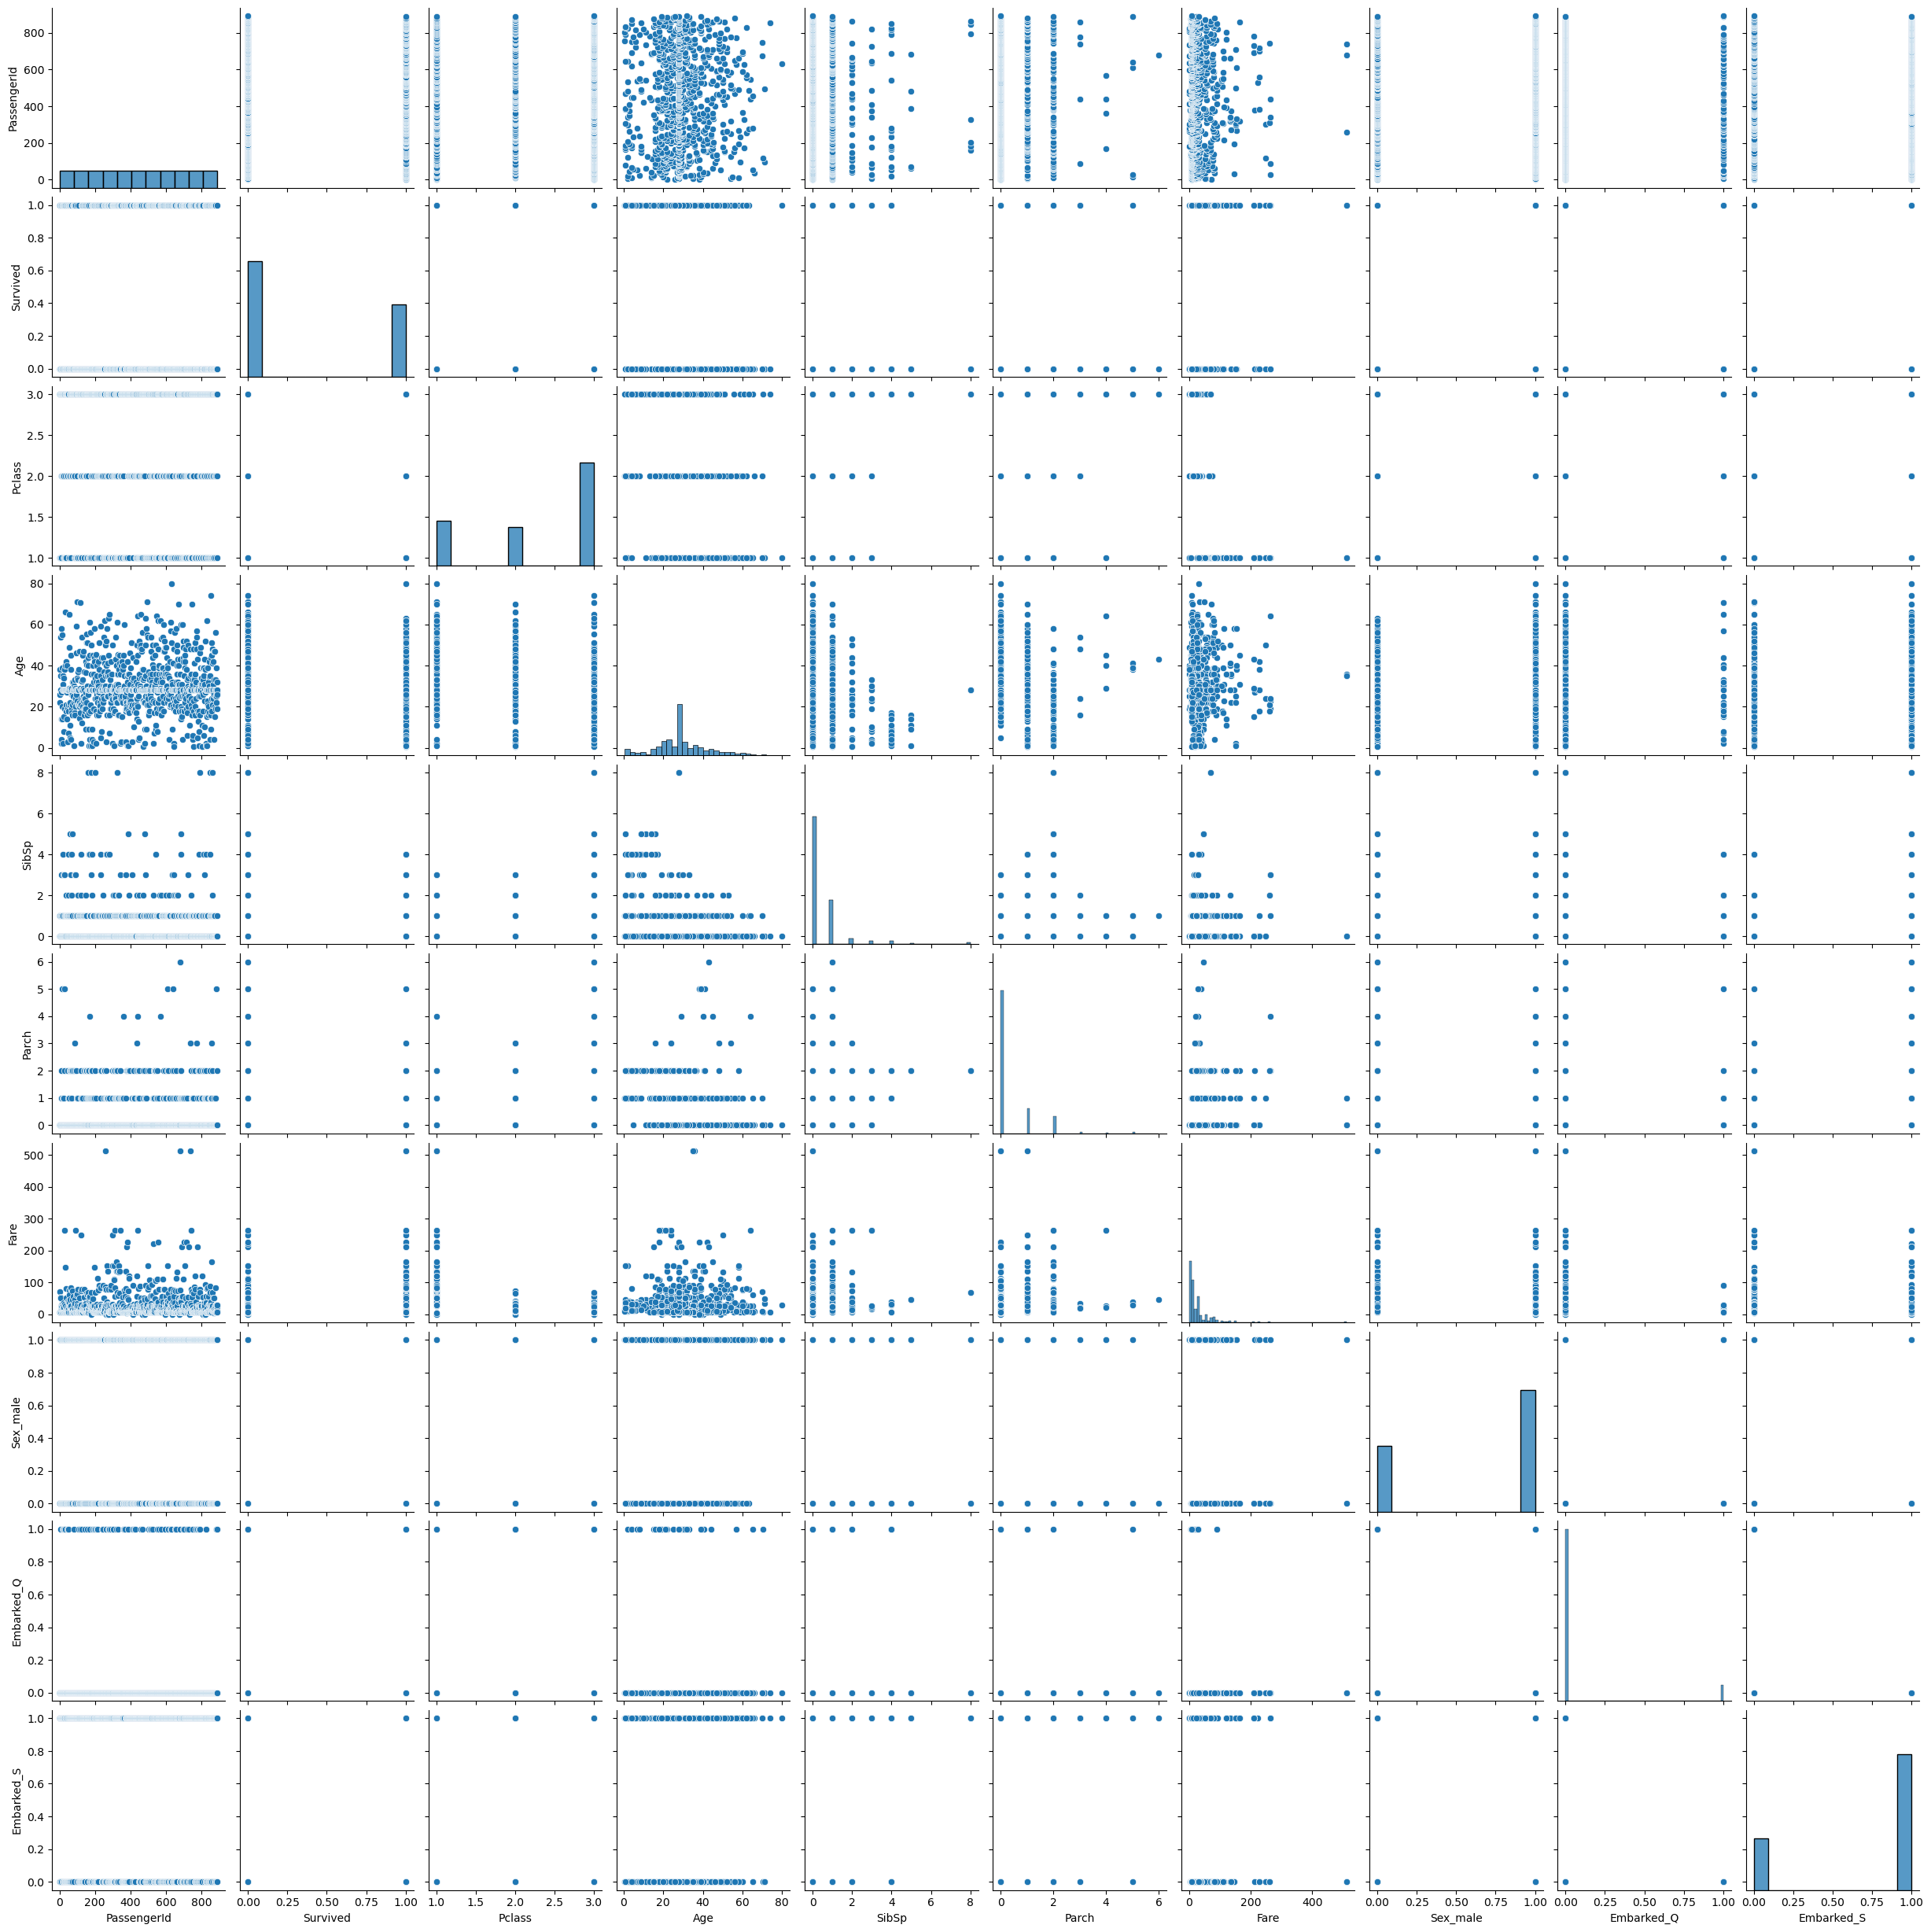

In [4]:
import seaborn as sns
sns.pairplot(dataset)

In [6]:
dataset[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch','Sex_male']].corr()


,Survived,Pclass,Age,SibSp,Parch,Sex_male
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,-0.543351
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,0.131900
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.081163
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,-0.114631
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,-0.245489
Sex_male,-0.543351,0.131900,0.081163,-0.114631,-0.245489,1.000000


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_Vif(X):
    # Creating an empty DataFrame to store VIF results
    Vif=pd.DataFrame()
    # Adding a column "variables" containing the names of all columns in X
    Vif["variables"]=X.columns
    # Calculating VIF for each variable:
    # - Looping through each column index i in X
    # - variance_inflation_factor(X.values, i) computes VIF for column i
    Vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    # Returning the final DataFrame containing variable names and their VIFs
    return Vif


In [9]:
calc_Vif(dataset[["Parch","Survived"]])

,variables,VIF
0,Parch,1.11658
1,Survived,1.11658


In [10]:
calc_Vif(dataset[["Pclass","Survived"]])

,variables,VIF
0,Pclass,1.319606
1,Survived,1.319606


In [11]:
calc_Vif(dataset[["Age","Survived"]])

,variables,VIF
0,Age,1.424229
1,Survived,1.424229


In [12]:
calc_Vif(dataset[["SibSp","Survived"]])

,variables,VIF
0,SibSp,1.061426
1,Survived,1.061426


In [13]:
calc_Vif(dataset[["Sex_male","Survived"]])

,variables,VIF
0,Sex_male,1.064065
1,Survived,1.064065
